# Дискретно-событийная модель SIR
Базовый опыт главы 8: 990 восприимчивых, 10 заразных, β=0.05,
c=10 контактов в день, γ=0.25, горизонт 40 дней, seed=1234.
Каждая восприимчивая особь независимо ожидает контакт; партнёр выбирается
среди остальных живых особей. Время выздоровления экспоненциальное.

In [1]:
using DrWatson
@quickactivate "project"
using project.SIRDES
using CSV, DataFrames, Statistics, StatsPlots
include(srcdir("experiments.jl"))
using .Experiments

In [2]:
u0 = [990,10,0]
p = [.05,10.0,.25]
T = 40.0
model, result = simulate(u0=u0,p=p,T=T,seed=1234);

## Журнал событий
t — время события; S/I/R — численности после события. E=0 в SIR.
Последняя строка фиксирует состояние на горизонте, а не окончание эпидемии.

In [3]:
trajectory = out(model)
display(first(trajectory,8))
display(last(trajectory,5))

Row,t,S,E,I,R,births,deaths,vaccinated,infections,event,person
,Float64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,String,Int64
1,0.0,990,0,10,0,0,0,0,0,initial,0
2,0.110851,989,0,11,0,0,0,0,1,infection,206
3,0.249585,988,0,12,0,0,0,0,2,infection,771
4,0.314392,987,0,13,0,0,0,0,3,infection,512
5,0.418738,987,0,12,1,0,0,0,3,recovery,996
6,0.457041,987,0,11,2,0,0,0,3,recovery,998
7,0.528895,986,0,12,2,0,0,0,4,infection,262
8,0.619502,985,0,13,2,0,0,0,5,infection,813


Row,t,S,E,I,R,births,deaths,vaccinated,infections,event,person
,Float64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,String,Int64
1,39.4599,228,0,22,750,0,0,0,762,recovery,916
2,39.7561,227,0,23,750,0,0,0,763,infection,410
3,39.8017,226,0,24,750,0,0,0,764,infection,46
4,39.9933,226,0,23,751,0,0,0,764,recovery,988
5,40.0,226,0,23,751,0,0,0,764,horizon,0


## Пик и состояние на 40-й день
R(T)/N — доля выздоровевших к T, но не финальный размер при I(T)>0.

In [4]:
summary = save_table("baseline",DataFrame([result]))
display(select(summary,:peak_I,:peak_time,:S_T,:I_T,:R_T,:R_fraction))

Row,peak_I,peak_time,S_T,I_T,R_T,R_fraction
,Int64,Float64,Int64,Int64,Int64,Float64
1,174,17.8722,226,23,751,0.751


## Динамика S/I/R

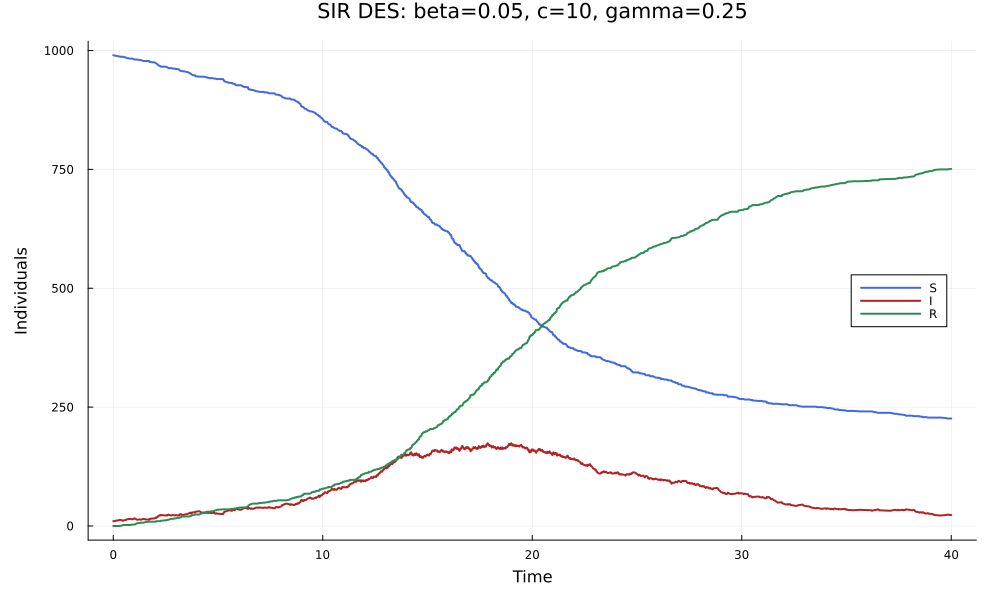

In [5]:
fig = plot_states(trajectory;title="SIR DES: beta=0.05, c=10, gamma=0.25")
savefig(fig,figure_path("01-plot"))
display(fig)